In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
df.isna().sum()

ZIP                          0
Total_Parks                  0
Total_Acres                  3
Total_Schools                0
Schools_Reported             0
Schools_Unreported           0
Schools_Percent_Reported     0
Total_Students               0
Students_Reported            0
Students_Unreported          0
Students_Percent_Reported    0
Grad_Avg                     6
ELA_Avg                      0
ELA_Part_Avg                 0
MATH_Avg                     0
MATH_Part_Avg                0
dtype: int64

In [42]:
(df == 0).sum()

ZIP                           0
Total_Parks                   3
Total_Acres                   0
Total_Schools                 0
Schools_Reported              0
Schools_Unreported           26
Schools_Percent_Reported      0
Total_Students                0
Students_Reported             0
Students_Unreported          27
Students_Percent_Reported     0
Grad_Avg                      0
ELA_Avg                       0
ELA_Part_Avg                  0
MATH_Avg                      0
MATH_Part_Avg                 0
dtype: int64

In [25]:
##Note regarding the NULL and 0 values: we will not count ZIP codes where we don't have parks to compare, and we will also not count ZIP codes where Grad Averages are not provided.

In [43]:
##What are the dimensions of the dataset?
df.shape

(51, 16)

In [44]:
##What is the distribution of numerical variables in the dataset?
df.describe()

,ZIP,Total_Parks,Total_Acres,Total_Schools,Schools_Reported,Schools_Unreported,Schools_Percent_Reported,Total_Students,Students_Reported,Students_Unreported,Students_Percent_Reported,Grad_Avg,ELA_Avg,ELA_Part_Avg,MATH_Avg,MATH_Part_Avg
count,51.000000,51.000000,48.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,4.500000e+01,51.000000,51.000000,51.000000,51.000000
mean,60636.607843,11.745098,2717.989792,12.784314,12.058824,0.725490,94.156863,84045.117647,6236.764706,143.039216,97.647059,8.560000e+01,42.744706,96.370196,29.161176,96.143529
std,33.232561,6.330381,4357.520749,8.132192,7.852163,0.939754,8.020904,68499.131530,3851.129661,193.352110,3.724640,5.748574e-14,15.911968,3.240698,16.541180,3.291768
min,60602.000000,0.000000,5.420000,1.000000,1.000000,0.000000,70.000000,839.000000,839.000000,0.000000,85.000000,8.560000e+01,19.630000,77.200000,10.750000,76.650000
25%,60618.500000,7.500000,442.982500,6.500000,6.000000,0.000000,91.000000,32411.500000,3751.500000,0.000000,96.500000,8.560000e+01,31.085000,95.665000,17.340000,95.360000
50%,60632.000000,11.000000,863.060000,12.000000,11.000000,0.000000,100.000000,63624.000000,5368.000000,0.000000,100.000000,8.560000e+01,37.310000,97.000000,22.430000,96.820000
75%,60645.500000,16.000000,2797.162500,17.500000,17.000000,1.000000,100.000000,123351.000000,7716.000000,262.500000,100.000000,8.560000e+01,50.605000,98.030000,38.585000,97.875000
max,60827.000000,24.000000,22546.890000,34.000000,34.000000,4.000000,100.000000,264730.000000,19511.000000,704.000000,100.000000,8.560000e+01,90.500000,99.020000,84.300000,99.020000


In [60]:
##Let's find any correlation between ELA and Math rates. First, to avoid skewed data, comparing ZIP codes where all students are reported AND parks are 0. We will not address Grad Rates yet as exluding those will exclude valuable subject rates data. We dill do Grade Rates, separately, later:
df_subjects = df[(df['Students_Unreported'] == 0) & (df['Total_Parks'] != 0)].copy()

##I also want to create on additional metric that may be helpful:
df_subjects['Density'] = df_subjects['Students_Reported'] / df_subjects['Total_Parks']

##Correlations:
parks_ELA = df_subjects['Total_Parks'].corr(df_subjects['ELA_Avg'])
parks_MATH = df_subjects['Total_Parks'].corr(df_subjects['MATH_Avg'])
acres_ELA = df_subjects['Total_Acres'].corr(df_subjects['ELA_Avg'])
acres_MATH = df_subjects['Total_Acres'].corr(df_subjects['MATH_Avg'])
students_ELA = df_subjects['Students_Reported'].corr(df_subjects['ELA_Avg'])
students_MATH = df_subjects['Students_Reported'].corr(df_subjects['MATH_Avg'])
density_ELA = df_subjects['Density'].corr(df_subjects['ELA_Avg'])
density_MATH = df_subjects['Density'].corr(df_subjects['MATH_Avg'])
print("The correlations are as follows:")
print(f"ELA Proficiency and Total Parks: {parks_ELA}")
print(f"MATH Proficiency and Total Parks: {parks_MATH}")
print(f"ELA Proficiency and Total Acres: {acres_ELA}")
print(f"MATH Proficiency and Total Acres: {acres_MATH}")
print(f"ELA Proficiency and Total Students (Reported): {students_ELA}")
print(f"MATH Proficiency and Total Students (Reported): {students_MATH}")
print(f"ELA Proficiency and Student-to-Park Density: {density_ELA}")
print(f"MATH Proficiency and Student-to-Park Density: {density_MATH}")

The correlations are as follows:
ELA Proficiency and Total Parks: -0.42817270926961704
MATH Proficiency and Total Parks: -0.33193903237815314
ELA Proficiency and Total Acres: -0.3095820701626023
MATH Proficiency and Total Acres: -0.2936836556194212
ELA Proficiency and Total Students (Reported): -0.3986552376419624
MATH Proficiency and Total Students (Reported): -0.3365167460423211
ELA Proficiency and Student-to-Park Density: -0.13255264507334827
MATH Proficiency and Student-to-Park Density: -0.15145219871916565


Text(0.5, 1.0, 'Total Parks and Subject Rates in Chicago')

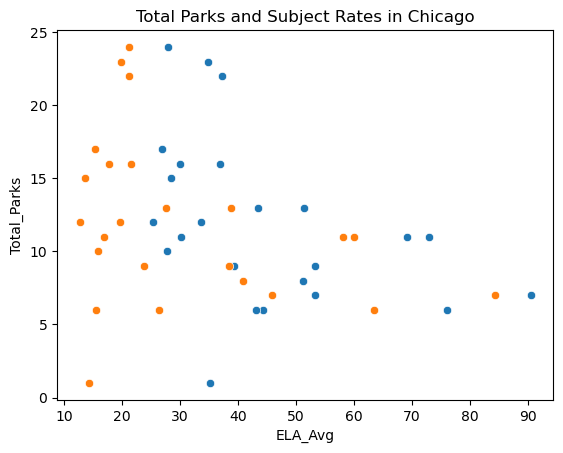

In [62]:
##Visuals:
sns.scatterplot(data=df_subjects, x='ELA_Avg', y='Total_Parks')
sns.scatterplot(data=df_subjects, x='MATH_Avg', y='Total_Parks')
plt.title('Total Parks and Subject Rates in Chicago')

Text(0.5, 1.0, 'Total Acres and Subject Rates in Chicago')

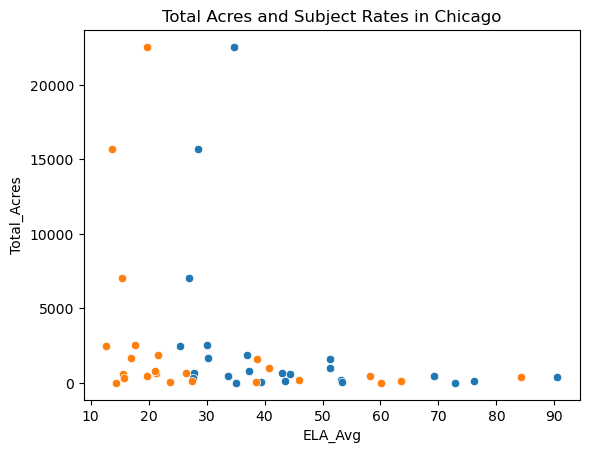

In [63]:
sns.scatterplot(data=df_subjects, x='ELA_Avg', y='Total_Acres')
sns.scatterplot(data=df_subjects, x='MATH_Avg', y='Total_Acres')
plt.title('Total Acres and Subject Rates in Chicago')

Text(0.5, 1.0, 'Total Students (Reported) and Subject Rates in Chicago')

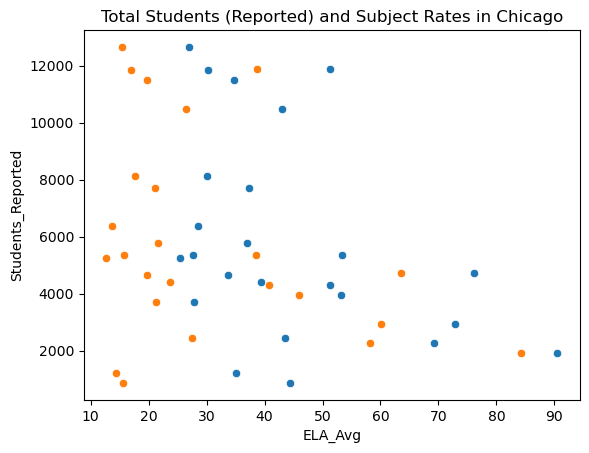

In [64]:
sns.scatterplot(data=df_subjects, x='ELA_Avg', y='Students_Reported')
sns.scatterplot(data=df_subjects, x='MATH_Avg', y='Students_Reported')
plt.title('Total Students (Reported) and Subject Rates in Chicago')

Text(0.5, 1.0, 'Students per Park and Subject Rates in Chicago')

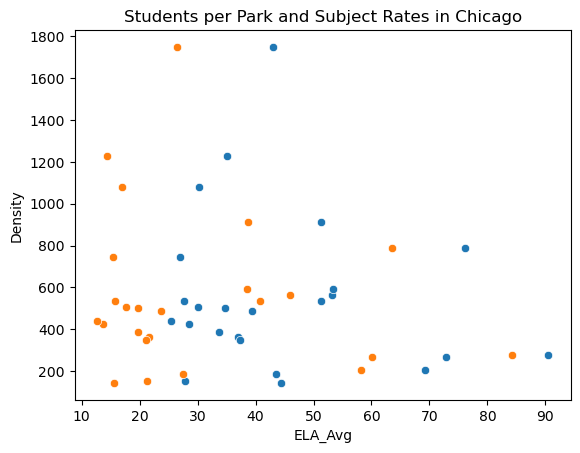

In [65]:
sns.scatterplot(data=df_subjects, x='ELA_Avg', y='Density')
sns.scatterplot(data=df_subjects, x='MATH_Avg', y='Density')
plt.title('Students per Park and Subject Rates in Chicago')

In [78]:
##In summary, there is a negative correlation in each of these comparisons. Most notably: the data suggests the higher the student density (students per park), the lower the subject rates. It also suggests the higher the number of parks (suggesting lower density), the lower the subject rates. Given that both Parks and Students are variables that can change, it's important to see both of these numbers in context:
top_5_students = df_subjects.nlargest(5, 'Students_Reported')[['ELA_Avg', 'MATH_Avg', 'Students_Reported']]
lower_5_students = df_subjects.nsmallest(5, 'Students_Reported')[['ELA_Avg', 'MATH_Avg', 'Students_Reported']]
top_5_density = df_subjects.nlargest(5, 'Density')[['ELA_Avg', 'MATH_Avg', 'Density']]
lower_5_density = df_subjects.nsmallest(5, 'Density')[['ELA_Avg', 'MATH_Avg', 'Density']]
print(f"The subject rates for the ZIP Codes with Highest and Lowest number of students reported is:")
print()
print(f"Highest: \n{top_5_students}")
print()
print(f"Lowest: \n{lower_5_students}")
print()
print("Compared to the ZIP Codes with the Highest and Lowest densities:")
print()
print(f"Highest: \n{top_5_density}")
print()
print(f"Lowest: \n{lower_5_density}")

The subject rates for the ZIP Codes with Highest and Lowest number of students reported is:

Highest: 
    ELA_Avg  MATH_Avg  Students_Reported
17    26.94     15.32              12661
19    51.34     38.73              11877
31    30.22     16.95              11856
11    34.80     19.74              11510
27    43.08     26.43              10495

Lowest: 
    ELA_Avg  MATH_Avg  Students_Reported
26    44.40     15.55                865
0     35.10     14.30               1226
1     90.50     84.30               1933
38    69.22     58.18               2258
32    43.46     27.54               2429

Compared to the ZIP Codes with the Highest and Lowest densities:

Highest: 
    ELA_Avg  MATH_Avg      Density
27    43.08     26.43  1749.166667
0     35.10     14.30  1226.000000
31    30.22     16.95  1077.818182
19    51.34     38.73   913.615385
2     76.10     63.56   789.166667

Lowest: 
    ELA_Avg  MATH_Avg     Density
26    44.40     15.55  144.166667
20    27.89     21.28  154.166

In [84]:
#This is a bit difficult to parse visually so we can calculate the averages for simplicity:

high_dense_ELA_avg = top_5_density['ELA_Avg'].mean()
print(high_dense_ELA_avg)

47.168


In [85]:
low_dense_ELA_avg = lower_5_density['ELA_Avg'].mean()
print(low_dense_ELA_avg)

51.57000000000001


In [89]:
high_dense_MATH_avg = top_5_density['MATH_Avg'].mean()
print(high_dense_MATH_avg)

31.994


In [90]:
low_dense_MATH_avg = lower_5_density['MATH_Avg'].mean()
print(low_dense_MATH_avg)

36.516000000000005
